## 1. Data Analysis - Set up and Data Loading

In [1]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(7)


In [2]:
import os
print("Files in /content/:")
print(os.listdir('/content/'))

Files in /content/:
['.config', 'Customer-Churn-Records.csv', 'sample_data']


In [3]:
# Load the dataset
df = pd.read_csv('Customer-Churn-Records.csv')

print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset has 10000 rows and 18 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
# Basic data quality check
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

print(f"Duplicates: {df.duplicated().sum()}")
print(f"Unique customers: {df['CustomerId'].nunique()}")

No missing values
Duplicates: 0
Unique customers: 10000


In [5]:
# Define feature categories for analysis
# Features to exclude from analysis (identifiers, not predictive)
id_features = ['RowNumber', 'CustomerId', 'Surname']

# Numeric features for correlation and statistical analysis
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                   'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                   'Complain', 'Satisfaction Score', 'Point Earned']

# Categorical features
categorical_features = ['Geography', 'Gender', 'Card Type']

# Target variable
target = 'Exited'

## 2. Data Analysis - Class Distribution Analysis

Understanding the target variable distribution is critical for:
- Determining appropriate evaluation metrics
- Selecting imbalance handling strategies
- Setting realistic performance expectations

Retained: 7962 (79.62%)
Churned: 2038 (20.38%)
Ratio: 3.91:1


Text(0.5, 1.0, 'Customer Churn Proportion')

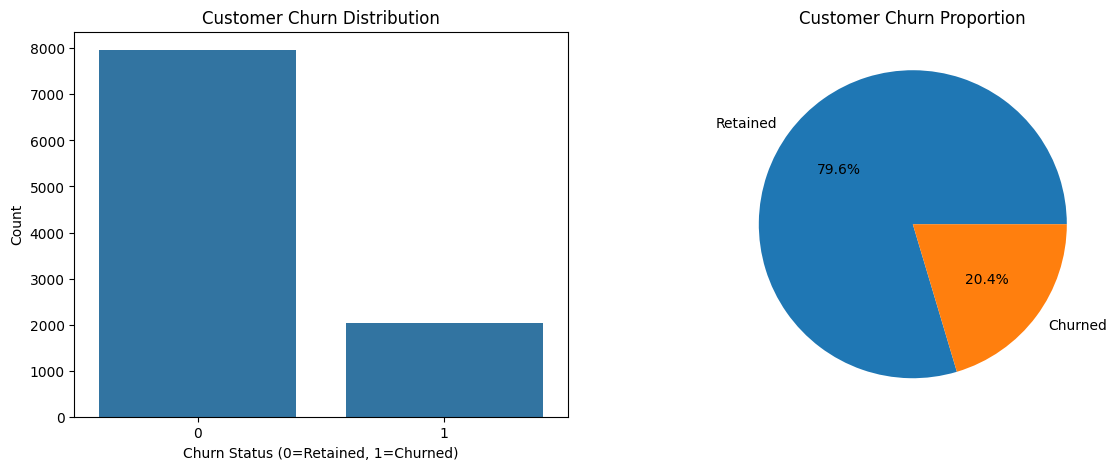

In [6]:
# Analyze target variable distribution
churn_counts = df[target].value_counts()
churn_percent = (df[target].value_counts(normalize=True) * 100).round(2)

print(f"Retained: {churn_counts[0]} ({churn_percent[0]}%)")
print(f"Churned: {churn_counts[1]} ({churn_percent[1]}%)")
print(f"Ratio: {round(churn_counts[0]/churn_counts[1], 2)}:1")

# Plot to show churn visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(data=df, x=target, ax=axes[0])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn Status (0=Retained, 1=Churned)')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%')
axes[1].set_title('Customer Churn Proportion')


**Interpretation (Figure 1):**

The churn rate of approximately 20% represents a meaningful but manageable class imbalance.

- **Modeling Strategy**: While not severely imbalanced, this distribution means that a naive model predicting "no churn" for all customers would achieve 80% accuracy but miss all churners entirely.

- **Evaluation Metrics**: Accuracy alone will be insufficient. The analysis will prioritize recall (capturing true churners) and F1-score (balancing precision and recall) when evaluating models.

- **Imbalance Handling**: We will compare three approaches in Phase 3:
  1. No resampling (baseline)
  2. Class weights
  3. SMOTE

- **Business Context**: A 20% churn rate indicates significant customer attrition that warrants proactive intervention strategies.

# 3. Data Analysis - Descriptive Statistics

Comprehensive statistical summary to understand feature distributions and identify potential outliers.

In [7]:
# Generate detailed descriptive statistics for Numeric Features
desc_stats = df[numeric_features].describe().T
# Add columns for variance (how spread the data is), skewness (how balanced data is), and kurtosis (peak or flat data)
desc_stats['variance'] = df[numeric_features].var()
desc_stats['skewness'] = df[numeric_features].skew()
desc_stats['kurtosis'] = df[numeric_features].kurtosis()

# Display variance without scientific notation
pd.options.display.float_format = '{:.2f}'.format

desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00,9341.86,-0.07,-0.43
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00,109.99,1.01,1.40
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00,8.36,0.01,-1.17
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09,3893436175.99,-0.14,-1.49
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00,0.34,0.75,0.58
HasCrCard,10000.00,0.71,0.46,0.00,0.00,1.00,1.00,1.00,0.21,-0.90,-1.19
IsActiveMember,10000.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00,0.25,-0.06,-2.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48,3307456784.13,0.00,-1.18
Complain,10000.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,0.16,1.47,0.15
Satisfaction Score,10000.00,3.01,1.41,1.00,2.00,3.00,4.00,5.00,1.98,-0.01,-1.29


In [8]:
# Identify features with high skewness (skew > 1 or skew < -1)
# Check both right-skewed (positive) and left-skewed (negative)
right_skewed = desc_stats['skewness'] > 1
left_skewed = desc_stats['skewness'] < -1
high_skew = desc_stats[right_skewed | left_skewed]['skewness']

if high_skew.empty:
    print("No features with extreme skewness")
else:
    for feature, skew_val in high_skew.items():
        direction = "right-skewed" if skew_val > 0 else "left-skewed"
        print(f"{feature}: {round(skew_val, 3)} ({direction})")

Age: 1.011 (right-skewed)
Complain: 1.466 (right-skewed)


# 4. Data Analysis - Correlation Analysis

**Objective**: Identify relationships between numeric features to:
- Understand feature relationships with the target variable
- Inform feature selection decisions

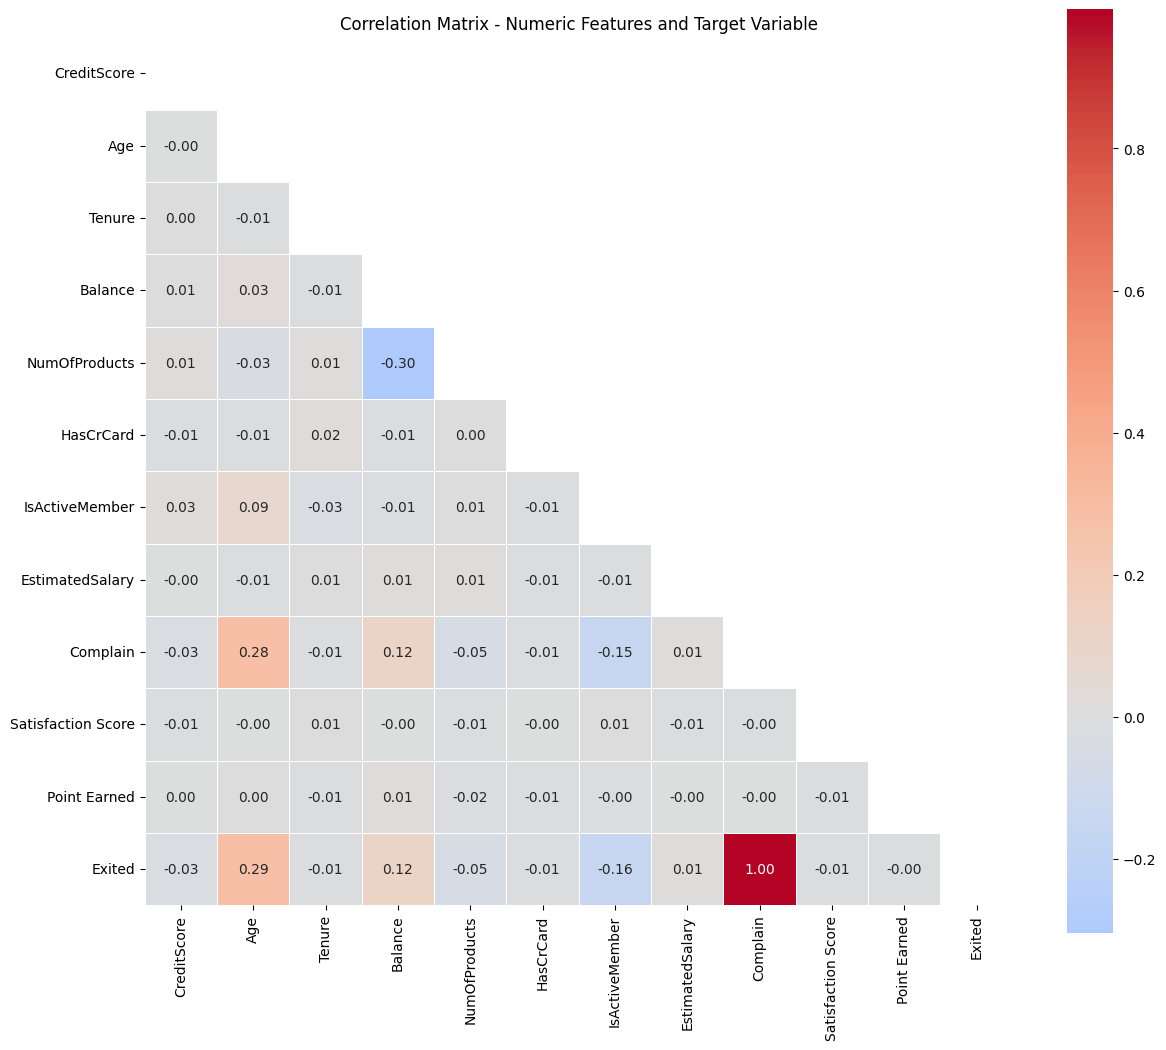

In [9]:
# Calculate correlation matrix - combine list of numaeric features and target feature, calculate corr between columns
corr_features = numeric_features + [target]
correlation_matrix = df[corr_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numeric Features and Target Variable')
plt.savefig('figure_02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Identify strong correlations with target variable
target_corr = correlation_matrix[target].drop(target).sort_values(ascending=False)

print("Top positive correlations:")
print(target_corr.head(5))

print("\nTop negative correlations:")
print(target_corr.tail(5))

Top positive correlations:
Complain           1.00
Age                0.29
Balance            0.12
EstimatedSalary    0.01
Point Earned      -0.00
Name: Exited, dtype: float64

Top negative correlations:
HasCrCard        -0.01
Tenure           -0.01
CreditScore      -0.03
NumOfProducts    -0.05
IsActiveMember   -0.16
Name: Exited, dtype: float64


**Data Leakage - Feature Removal Required**

**Finding:** The feature Complain shows a correlation of **1.00** with the target variable Exited (churn). This indicates an almost perfect linear relationship.

**Why This Is a Problem:**

1. **Data Leakage**: A correlation of 1.00 suggests that Complain is not a predictor of churn - it's essentially a duplicate of the churn outcome itself. This means:
   - If Complain = 1 → Customer churned (100% of the time)
   - If Complain = 0 → Customer stayed (100% of the time)

This means:
   - We cannot use Complain to predict future churn
   - By the time a complaint is registered, the customer has already churned or is in the process of churning
   - The feature provides no predictive value for proactive intervention

2. Including this feature would create an artificially perfect model that:
   - Achieves near-100% accuracy in training
   - Fails completely in production (where complaint data won't be available before churn)
   - Provides no actionable business insights

**Decision:** The Complain feature will be **removed** from the dataset before model training.

**Impact on Analysis:**
- After removing Complain, the next strongest predictors are:
  - **Age (0.29)**: Older customers are more likely to churn
  - **IsActiveMember (-0.16)**: Active members are less likely to churn
  - **Balance (0.12)**: Customers with higher balances show slightly higher churn

# 5. Data Analysis - Churn Specific Analysis

5.1 Numeric Feature Churn Analysis

**Objective**: Compare characteristics of churned vs. retained customers to identify behavioral and demographic differences.

In [11]:
# Compare means for churned vs. retained customers
churn_comparison = df.groupby(target)[numeric_features].mean().T
churn_comparison.columns = ['Retained', 'Churned']
churn_comparison['Difference'] = churn_comparison['Churned'] - churn_comparison['Retained']
churn_comparison['Pct_Change'] = (churn_comparison['Difference'] / churn_comparison['Retained']) * 100

churn_comparison.round(2)

,Retained,Churned,Difference,Pct_Change
CreditScore,651.84,645.41,-6.42,-0.99
Age,37.41,44.84,7.43,19.86
Tenure,5.03,4.93,-0.10,-1.95
Balance,72742.75,91109.48,18366.73,25.25
NumOfProducts,1.54,1.48,-0.07,-4.45
HasCrCard,0.71,0.70,-0.01,-1.12
IsActiveMember,0.55,0.36,-0.19,-34.98
EstimatedSalary,99726.85,101509.91,1783.06,1.79
Complain,0.00,1.00,1.00,79363.73
Satisfaction Score,3.02,3.00,-0.02,-0.68


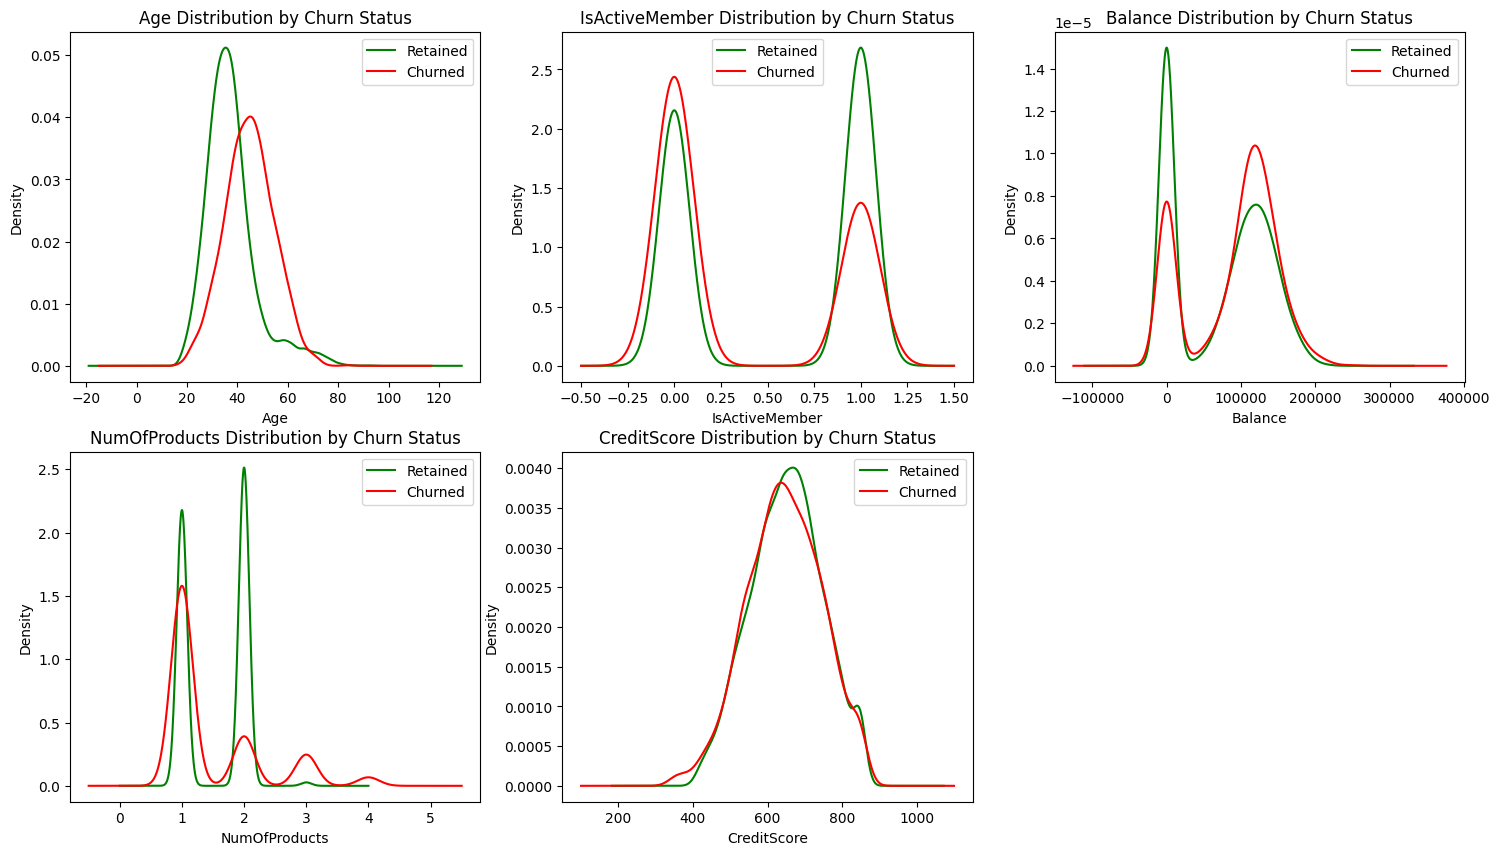

In [12]:
# Visualize key feature distributions by churn status
# Features with meaningful correlations (excluding Complain due to data leakage)
# Positive: Age (0.29), Balance (0.12)
# Negative: IsActiveMember (-0.16), NumOfProducts (-0.05), CreditScore (-0.03)
key_features = ['Age', 'IsActiveMember', 'Balance', 'NumOfProducts', 'CreditScore']

# Use 2x3 grid for better layout (6 slots, 5 used, 1 empty)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Plot distributions
    retained = df[df[target] == 0][feature]
    churned = df[df[target] == 1][feature]

    retained.plot(kind='kde', ax=axes[idx], label='Retained', color='green')
    churned.plot(kind='kde', ax=axes[idx], label='Churned', color='red')

    axes[idx].set_title(f'{feature} Distribution by Churn Status')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

# Hide the last unused subplot
axes[-1].set_visible(False)

plt.savefig('figure_04_numeric_distributions_by_churn.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

**Strong Predictors (Clear Separation):**
- **Age**: Churned customers peak around age 45 vs. retained customers at age 35. Older customers show significantly higher churn propensity, confirming Age as the strongest predictor (r=0.29).
- **IsActiveMember**: Churned customers concentrate at 0 (inactive) while retained customers peak at 1 (active). Inactive members are substantially more likely to churn (r=-0.16).
- **NumOfProducts**: Churned customers typically have 1 product, while retained customers have 2+ products. Cross-selling demonstrates retention value (r=-0.05).

**Weak Predictors (High Overlap):**
- **Balance**: Both churned and retained customers show two common patterns - either $0 balance or around $125K balance. Since both groups have similar balance distributions, this feature doesn't help distinguish who will churn (r=0.12).
- **CreditScore**: Nearly perfect overlap centered around 650. Credit score shows no discriminative ability for churn prediction (r=-0.03).

**Business Implications:**
- Prioritize retention campaigns for customers aged 45+
- Re-engage inactive members (highest churn risk)
- Promote cross-selling to increase product ownership
- Credit score screening not necessary for churn interventions

These patterns suggest tree-based models (Random Forest, Decision Trees) will perform better than linear models (Logistic Regression) because the relationships aren't straightforward. For example, having 1 product is bad, 2 products is good, but 3-4 products might be bad again - that's a non-linear pattern that trees can capture but linear models struggle with.

# **5.2 Categorical feature churn analysis**

In [13]:
# Churn rates by categorical features
for feature in categorical_features:
    print(f"\n{feature}:")
    churn_rate = df.groupby(feature)[target].agg(['sum', 'count', 'mean'])
    churn_rate.columns = ['Churned', 'Total', 'Rate']
    churn_rate['Rate_Pct'] = churn_rate['Rate'] * 100
    print(churn_rate.round(2))


Geography:
           Churned  Total  Rate  Rate_Pct
Geography                                
France         811   5014  0.16     16.17
Germany        814   2509  0.32     32.44
Spain          413   2477  0.17     16.67

Gender:
        Churned  Total  Rate  Rate_Pct
Gender                                
Female     1139   4543  0.25     25.07
Male        899   5457  0.16     16.47

Card Type:
           Churned  Total  Rate  Rate_Pct
Card Type                                
DIAMOND        546   2507  0.22     21.78
GOLD           482   2502  0.19     19.26
PLATINUM       508   2495  0.20     20.36
SILVER         502   2496  0.20     20.11


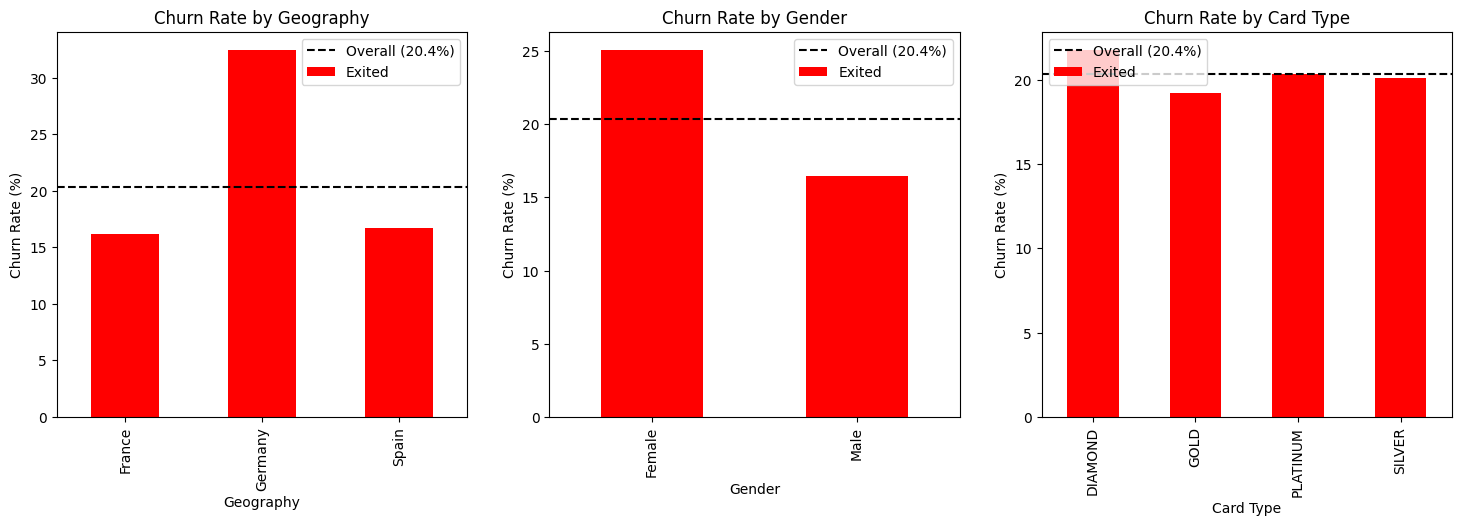

In [14]:
# Visualize churn rates by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(categorical_features):
    churn_rate = df.groupby(feature)[target].mean() * 100

    churn_rate.plot(kind='bar', ax=axes[idx], color='red')
    axes[idx].set_title(f'Churn Rate by {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].axhline(y=df[target].mean()*100, color='black', linestyle='--',
                     label=f'Overall ({round(df[target].mean()*100, 1)}%)')
    axes[idx].legend()

plt.savefig('figure_05_categorical_churn_rates.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

The categorical churn rate analysis reveals significant geographic and demographic patterns:

**Geography - Strong Predictor:**
- **Germany**: 32.44% churn rate (double the overall average) - Critical risk market
- **France**: 16.17% churn rate (below average)
- **Spain**: 16.67% churn rate (below average)
- **Insight**: German customers are 2x more likely to churn than French/Spanish customers. This may suggest market specific factors (competition, service quality, pricing) driving churn in Germany.

**Gender - Moderate Predictor:**
- **Female**: 25.07% churn rate (52% higher than males)
- **Male**: 16.47% churn rate (below average)
- **Insight**: Female customers churn at higher rates.

**Card Type - Weak Predictor:**
- All card types show similar churn rates (19-22%)
- **Insight**: Card tier has minimal impact on churn. Premium card holders don't show better retention.


# **6. Data Analysis - Financial Exposure Analysis (Tied to RQ2)**


**Objective**: Understand the distribution of financial value among customers and identify high-exposure churn risk.

This section directly addresses **Research Question 2**: How does incorporating financial exposure alter prioritization?

In [15]:
# Analyze Balance distribution ACROSS ALL records
print(f"Mean balance: ${round(df['Balance'].mean(), 2)}")
print(f"Median balance: ${round(df['Balance'].median(), 2)}")
print(f"Std dev: ${round(df['Balance'].std(), 2)}")
print(f"Zero balance customers: {(df['Balance'] == 0).sum()} ({round((df['Balance'] == 0).mean()*100, 1)}%)")

Mean balance: $76485.89
Median balance: $97198.54
Std dev: $62397.41
Zero balance customers: 3617 (36.2%)


In [16]:
# Compare Balance distribution: Churned vs. Retained
balance_by_churn = df.groupby(target)['Balance'].describe()
balance_by_churn.index = ['Retained', 'Churned']
print(balance_by_churn.round(2))

# Calculate total financial exposure from churned customers
total_churned_balance = df[df[target] == 1]['Balance'].sum()
total_balance = df['Balance'].sum()
print(f"\nTotal at risk: ${round(total_churned_balance, 2)} ({round((total_churned_balance/total_balance)*100, 1)}% of deposits)")

           count     mean      std  min      25%       50%       75%       max
Retained 7962.00 72742.75 62851.58 0.00     0.00  92063.06 126419.33 221532.80
Churned  2038.00 91109.48 58346.48 0.00 38591.22 109344.23 131423.64 250898.09

Total at risk: $185681112.1 (24.3% of deposits)


/tmp/ipykernel_7190/2471942009.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_group = df.groupby('Balance_Group')[target].mean() * 100


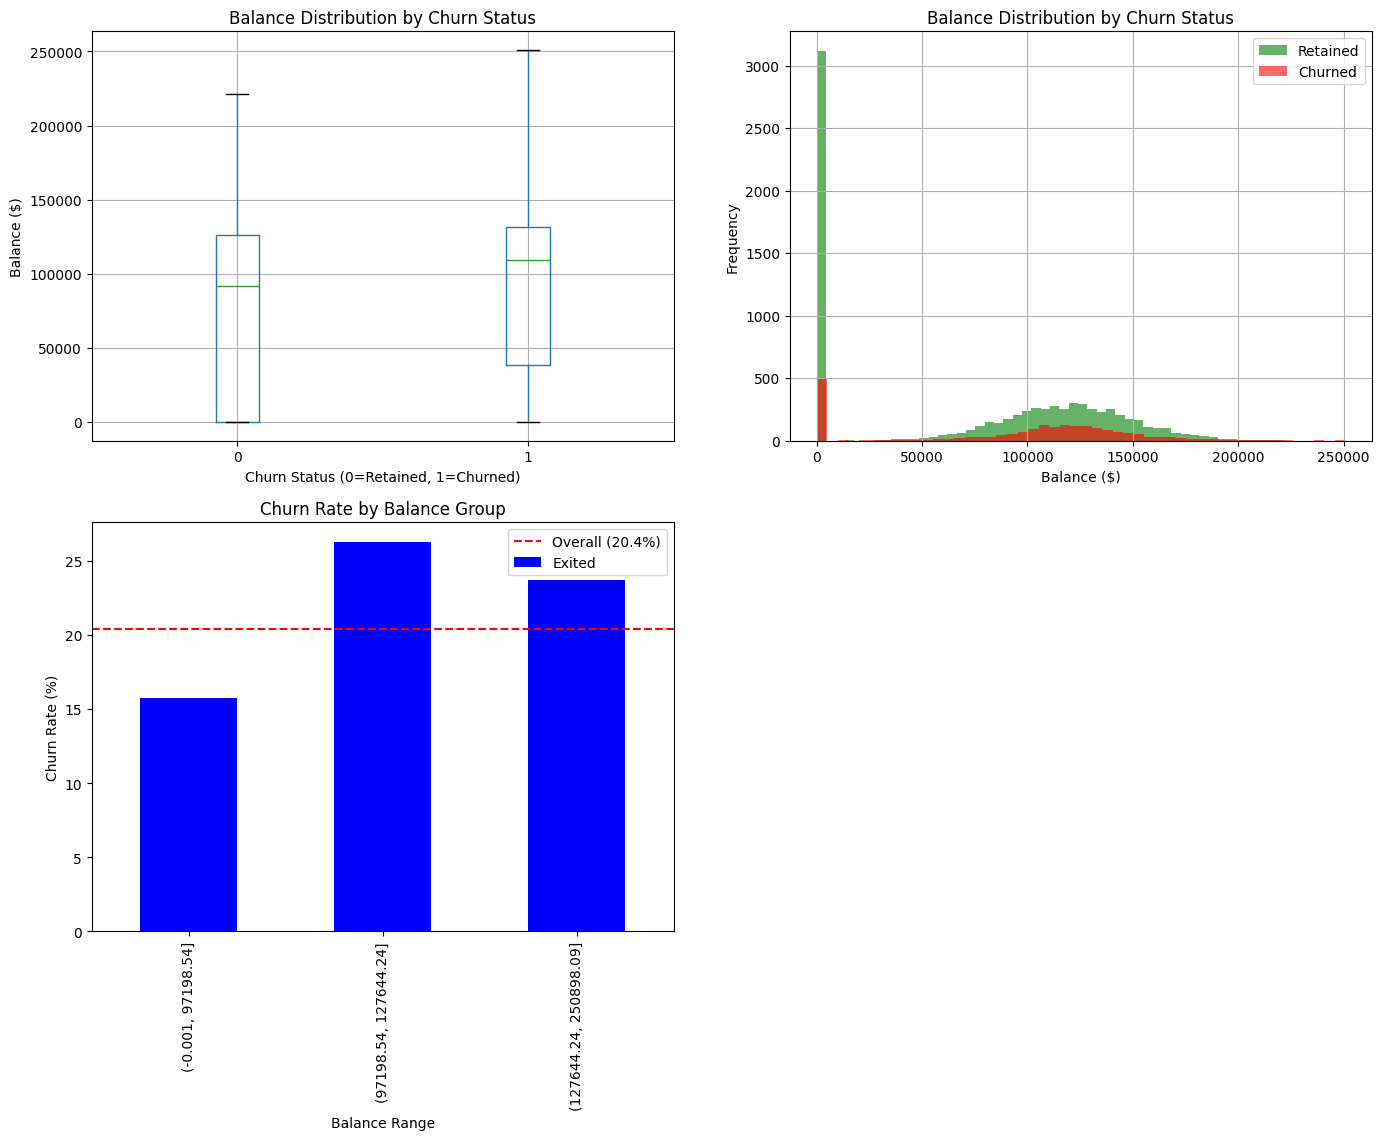

In [17]:
# Visualize Balance distribution by churn status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
df.boxplot(column='Balance', by=target, ax=axes[0, 0])
axes[0, 0].set_title('Balance Distribution by Churn Status')
axes[0, 0].set_xlabel('Churn Status (0=Retained, 1=Churned)')
axes[0, 0].set_ylabel('Balance ($)')
plt.suptitle('')

# Histogram
df[df[target] == 0]['Balance'].hist(bins=50, alpha=0.6, label='Retained', color='green', ax=axes[0, 1])
df[df[target] == 1]['Balance'].hist(bins=50, alpha=0.6, label='Churned', color='red', ax=axes[0, 1])
axes[0, 1].set_title('Balance Distribution by Churn Status')
axes[0, 1].set_xlabel('Balance ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Churn rate by balance groups
# Used duplicates='drop' because 36% have $0 balance
df['Balance_Group'] = pd.qcut(df['Balance'], q=4, duplicates='drop')
churn_by_group = df.groupby('Balance_Group')[target].mean() * 100

churn_by_group.plot(kind='bar', ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Churn Rate by Balance Group')
axes[1, 0].set_xlabel('Balance Range')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].axhline(y=df[target].mean()*100, color='red', linestyle='--',
                  label=f'Overall ({round(df[target].mean()*100, 1)}%)')
axes[1, 0].legend()

# Hide unused subplot (bottom right)
axes[1, 1].set_visible(False)

plt.savefig('figure_06_financial_exposure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:**

This analysis reveals financial risk for the bank as customers with higher balances are MORE likely to churn.

**Key Findings:**

**1. Churned Customers Have Higher Balances:**
- Avg churned customer balance: $91,109
- Avg retained customer balance: $72,743
- **Difference: $18,366 more per churned customer**

This is the worst-case scenario because the bank is losing its most valuable customers.

**2. Churn Risk Increases with Balance:**
The bar chart (bottom left) shows churn rates by balance group:
- **Low balance group** (0-97K): 15.6% churn rate (BELOW the 20.4% average) - Lower financial risk
- **Medium balance group** (97K-127K): 26.9% churn rate (ABOVE average) - Higher financial risk  
- **High balance group** (127K-250K): 23.5% churn rate (ABOVE average) - Highest financial impact

Customers with balances above $97K (the median) churn at rates **25-30% higher** than low-balance customers.

**3. Total Financial Exposure:**
- **$185.7 million** at risk from churned customers
- This represents **24.3% of total deposits**

**4. Zero Balance Customers:**
- 36.2% of customers have $0 balance

**Implications for RQ2:**
- Not all churners are equal
- A single high-balance churner (125K) costs the bank as much as 10+ low-balance churners

# **7. Data Preperation - Feature Selection**

In [18]:
# Create a copy of the data
df_prep = df.copy()

# Remove identifier columns that were stored in section 1 (not predictive)
df_prep = df_prep.drop(columns=id_features)

print(f"Removed columns: {id_features}")
print(f"\nRemaining features: {df_prep.columns.tolist()}")

Removed columns: ['RowNumber', 'CustomerId', 'Surname']

Remaining features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'Balance_Group']


In [19]:
# Remove 'Complain' feature due to data leakage
if 'Complain' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Complain'])

# Remove 'Balance_Group' feature due to data leakage
if 'Balance_Group' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Balance_Group'])


# Separate features and target
X = df_prep.drop(columns=[target])
y = df_prep[target]

In [20]:
# Encode categorical variables
# Strategy: One-hot encoding for nominal variables, binary for Gender because it is a simple 2 options

# Binary encoding for Gender (0/1)
if 'Gender' in X.columns and X['Gender'].dtype == 'object':
    X['Gender'] = X['Gender'].map({'Female': 0, 'Male': 1})

# One-hot encoding for Geography (creates dummy variables for each country)
if 'Geography' in X.columns:
    geography_dummies = pd.get_dummies(X['Geography'], prefix='Geography')
    X = pd.concat([X.drop('Geography', axis=1), geography_dummies], axis=1)

# One-hot encoding for Card Type (creates dummy variables for each card type)
if 'Card Type' in X.columns:
    cardtype_dummies = pd.get_dummies(X['Card Type'], prefix='CardType')
    X = pd.concat([X.drop('Card Type', axis=1), cardtype_dummies], axis=1)

print(X.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_DIAMOND', 'CardType_GOLD', 'CardType_PLATINUM', 'CardType_SILVER']


# **8. Train/Test Split with Stratification**

In [21]:
from sklearn.model_selection import train_test_split

# Split with stratification to preserve class distribution - this keeps the same churn % in both sets
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  # Preserve churn rate in both sets
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain set churn rate: {round(y_train.mean()*100, 2)}%")
print(f"Test set churn rate: {round(y_test.mean()*100, 2)}%")
print(f"Original churn rate: {round(y.mean()*100, 2)}%")

Training set: (8000, 18)
Test set: (2000, 18)

Train set churn rate: 20.38%
Test set churn rate: 20.4%
Original churn rate: 20.38%


# **9. Feature Scaling**

In [22]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns that need scaling
# (Exclude binary/one-hot encoded features from earlier)
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary',
                'Satisfaction Score', 'Point Earned']

# Initialize scaler
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train[cols_to_scale])

# Transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling complete")
print(f"\nScaled features: {cols_to_scale}")
print(f"\nSample before scaling:")
print(X_train[cols_to_scale].iloc[0])
print(f"\nSample after scaling:")
print(X_train_scaled[cols_to_scale].iloc[0])

Scaling complete

Scaled features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

Sample before scaling:
CreditScore             709.00
Age                      35.00
Tenure                    2.00
Balance                   0.00
EstimatedSalary      104982.39
Satisfaction Score        2.00
Point Earned            422.00
Name: 4791, dtype: float64

Sample after scaling:
CreditScore           0.60
Age                  -0.37
Tenure               -1.04
Balance              -1.23
EstimatedSalary       0.10
Satisfaction Score   -0.72
Point Earned         -0.81
Name: 4791, dtype: float64


In [23]:
print("Columns in X_train_scaled:")
print(X_train_scaled.columns.tolist())

Columns in X_train_scaled:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'CardType_DIAMOND', 'CardType_GOLD', 'CardType_PLATINUM', 'CardType_SILVER']


# **10. Class Imbalance Handling Strategy**

In [24]:
from imblearn.over_sampling import SMOTE

# Strategy 1: No resampling (baseline)
X_train_baseline = X_train_scaled.copy()
y_train_baseline = y_train.copy()

# Strategy 2: SMOTE (Synthetic Minority Over-sampling)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Imbalance handling strategies prepared:")
print(f"\n1. Baseline (no resampling):")
print(f"   Shape: {X_train_baseline.shape}")
print(f"   Churn rate: {round(y_train_baseline.mean()*100, 2)}%")
print(f"   Class distribution: {y_train_baseline.value_counts().to_dict()}")

print(f"\n2. SMOTE (synthetic oversampling):")
print(f"   Shape: {X_train_smote.shape}")
print(f"   Churn rate: {round(y_train_smote.mean()*100, 2)}%")
print(f"   Class distribution: {y_train_smote.value_counts().to_dict()}")

Imbalance handling strategies prepared:

1. Baseline (no resampling):
   Shape: (8000, 18)
   Churn rate: 20.38%
   Class distribution: {0: 6370, 1: 1630}

2. SMOTE (synthetic oversampling):
   Shape: (12740, 18)
   Churn rate: 50.0%
   Class distribution: {0: 6370, 1: 6370}


# **11. Data Preperation Summary**

In [25]:
# Summary of prepared datasets

print(f"\nOriginal Dataset:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")

print(f"\nPreprocessed Features:")
print(f"  Total features: {X_train_scaled.shape[1]}")
print(f"  Removed: {len(id_features)} identifier columns")
print(f"  Encoded: {len(categorical_features)} categorical features")
print(f"  Scaled: {len(cols_to_scale)} numeric features")

print(f"\nDatasets Ready for Modeling:")
print(f"  X_train (unscaled): {X_train.shape} - For tree-based models")
print(f"  X_train_scaled: {X_train_scaled.shape} - For Logistic/SVM")
print(f"  X_train_smote: {X_train_smote.shape} - SMOTE resampled")
print(f"  X_test (unscaled): {X_test.shape}")
print(f"  X_test_scaled: {X_test_scaled.shape}")

print(f"\nTarget Variables:")
print(f"  y_train: {len(y_train)} samples ({y_train.sum()} churned)")
print(f"  y_train_smote: {len(y_train_smote)} samples ({y_train_smote.sum()} churned)")
print(f"  y_test: {len(y_test)} samples ({y_test.sum()} churned)")


Original Dataset:
  Rows: 10000
  Columns: 19

Preprocessed Features:
  Total features: 18
  Removed: 3 identifier columns
  Encoded: 3 categorical features
  Scaled: 7 numeric features

Datasets Ready for Modeling:
  X_train (unscaled): (8000, 18) - For tree-based models
  X_train_scaled: (8000, 18) - For Logistic/SVM
  X_train_smote: (12740, 18) - SMOTE resampled
  X_test (unscaled): (2000, 18)
  X_test_scaled: (2000, 18)

Target Variables:
  y_train: 8000 samples (1630 churned)
  y_train_smote: 12740 samples (6370 churned)
  y_test: 2000 samples (408 churned)


# **12. Model Training and Comparison**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Store results for comparison
cv_results = {}

# **12.1 Baseline Logistic Regression**

In [27]:
# Logistic Regression (uses scaled data)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Cross-validation scores
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')

cv_results['Logistic Regression'] = lr_scores

print(f"\nLogistic Regression:")
print(f"  F1-Score (mean): {lr_scores.mean():.4f}")
print(f"  F1-Score (std):  {lr_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in lr_scores]}")


Logistic Regression:
  F1-Score (mean): 0.3107
  F1-Score (std):  0.0182
  Individual folds: [np.float64(0.291), np.float64(0.3073), np.float64(0.3333), np.float64(0.3304), np.float64(0.2916)]


# # 12.2 Decision Tree Classifier

In [28]:
# Decision Tree (uses unscaled data)
dt_model = DecisionTreeClassifier(random_state=42)

# Cross-validation scores
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')

cv_results['Decision Tree'] = dt_scores

print(f"\nDecision Tree:")
print(f"  F1-Score (mean): {dt_scores.mean():.4f}")
print(f"  F1-Score (std):  {dt_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in dt_scores]}")


Decision Tree:
  F1-Score (mean): 0.4862
  F1-Score (std):  0.0146
  Individual folds: [np.float64(0.51), np.float64(0.4865), np.float64(0.4693), np.float64(0.4729), np.float64(0.4925)]


# **12.3 Random Forest Classifier**

In [29]:
# Random Forest (uses unscaled data)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

# Cross-validation scores
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')

cv_results['Random Forest'] = rf_scores

print(f"\nRandom Forest:")
print(f"  F1-Score (mean): {rf_scores.mean():.4f}")
print(f"  F1-Score (std):  {rf_scores.std():.4f}")
print(f"  Individual folds: {[round(s, 4) for s in rf_scores]}")


Random Forest:
  F1-Score (mean): 0.5600
  F1-Score (std):  0.0222
  Individual folds: [np.float64(0.532), np.float64(0.5764), np.float64(0.5927), np.float64(0.5569), np.float64(0.5418)]


# **Best Model = Random Forest**

# **12.4 Imbalance Handling Comparison**

In [30]:
# Compare imbalance strategies using best model (Random Forest)


# Strategy 1: Baseline (no resampling)
rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
baseline_scores = cross_val_score(rf_baseline, X_train_baseline, y_train_baseline, cv=5, scoring='f1')

print(f"\n1. Baseline (no resampling):")
print(f"   F1-Score: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

# Strategy 2: SMOTE
rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
smote_scores = cross_val_score(rf_smote, X_train_smote, y_train_smote, cv=5, scoring='f1')

print(f"\n2. SMOTE (synthetic oversampling):")
print(f"   F1-Score: {smote_scores.mean():.4f} ± {smote_scores.std():.4f}")

# Strategy 3: Class weights
rf_weighted = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
weighted_scores = cross_val_score(rf_weighted, X_train, y_train, cv=5, scoring='f1')

print(f"\n3. Class weights (balanced):")
print(f"   F1-Score: {weighted_scores.mean():.4f} ± {weighted_scores.std():.4f}")

# Select best strategy
best_strategy_scores = {'Baseline': baseline_scores.mean(),
                        'SMOTE': smote_scores.mean(),
                        'Weighted': weighted_scores.mean()}
best_strategy = max(best_strategy_scores, key=best_strategy_scores.get)

print(f"\n Best imbalance strategy: {best_strategy} (F1 = {best_strategy_scores[best_strategy]:.4f})")


1. Baseline (no resampling):
   F1-Score: 0.5627 ± 0.0221

2. SMOTE (synthetic oversampling):
   F1-Score: 0.8996 ± 0.0474

3. Class weights (balanced):
   F1-Score: 0.5428 ± 0.0192

 Best imbalance strategy: SMOTE (F1 = 0.8996)


# **Best Imbalance Strategy = SMOTE**

# **13. Hyperparameter Tuning**

In [31]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest (best performing model)
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Use SMOTE data
rf_grid.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best F1-Score: {rf_grid.best_score_:.4f}")

# Save best model
best_model = rf_grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1-Score: 0.9005


# **14. Model Calibration**

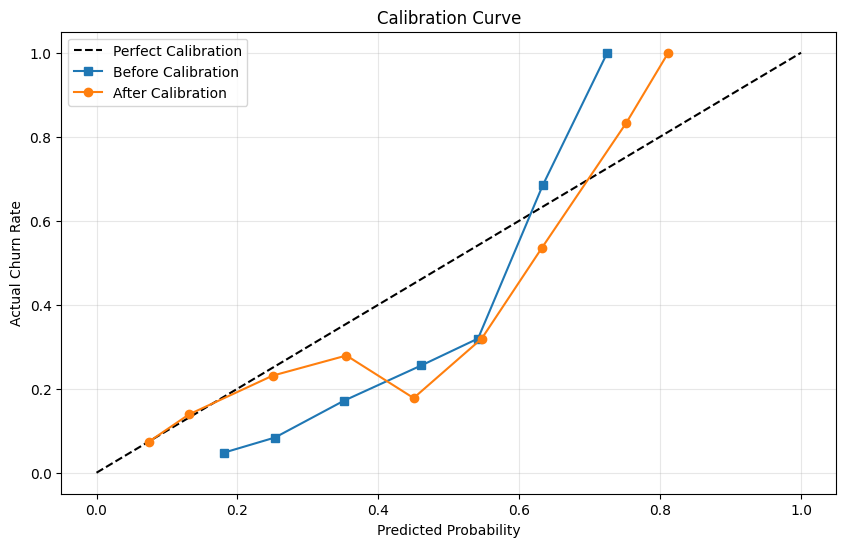

In [32]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Calibrate the best model for reliable probability estimates

# Create calibrated classifier
calibrated_model = CalibratedClassifierCV(best_model, cv=5, method='sigmoid')
calibrated_model.fit(X_train_smote, y_train_smote)  # SMOTE data


# Get predictions
y_pred_proba_uncal = best_model.predict_proba(X_test)[:, 1]
y_pred_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

# Plot calibration curves
fig, ax = plt.subplots(figsize=(10, 6))

# Perfectly calibrated line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

# Uncalibrated model
frac_pos_uncal, mean_pred_uncal = calibration_curve(y_test, y_pred_proba_uncal, n_bins=10)
ax.plot(mean_pred_uncal, frac_pos_uncal, 's-', label='Before Calibration')

# Calibrated model
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_pred_proba_cal, n_bins=10)
ax.plot(mean_pred_cal, frac_pos_cal, 'o-', label='After Calibration')

ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Actual Churn Rate')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig('figure_07_calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# **15. Model Evaluation (Precision, Recall, and F1-Score**

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Make predictions
y_pred = calibrated_model.predict(X_test)
y_pred_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (Of customers we predict will churn, what % actually churn?)")
print(f"Recall:    {recall:.4f}  (Of customers who actually churn, what % do we catch?)")
print(f"F1-Score:  {f1:.4f}  (Balance between Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f}  (Overall ability to distinguish churners from non-churners)")


Accuracy:  0.7655
Precision: 0.4182  (Of customers we predict will churn, what % actually churn?)
Recall:    0.3824  (Of customers who actually churn, what % do we catch?)
F1-Score:  0.3995  (Balance between Precision and Recall)
ROC-AUC:   0.7070  (Overall ability to distinguish churners from non-churners)


**Interpretation**: SMOTE achieved a high cross-validation score of 90%, but this performance did not translate to real-world data. When tested on actual customers, the F1-Score dropped significantly to 40%. This suggests the model overfit to the synthetic data patterns rather than learning genuine customer behaviors.

**Next Steps**: Next Steps: Based on these results, a different approach will be
used for hyperparameter tuning and business insights. This will be reflected in the final code output assignment.

**# Reverting to Baseline Approach**

# **14. Feature Importance Analysis**

In [40]:
# Extract feature importance from Random Forest
feature_names = X_train.columns
importances = best_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance_df.head(10).to_string(index=False))

           Feature  Importance
               Age        0.22
     NumOfProducts        0.12
           Balance        0.09
   EstimatedSalary        0.07
      Point Earned        0.07
       CreditScore        0.07
            Tenure        0.06
    IsActiveMember        0.06
Satisfaction Score        0.05
 Geography_Germany        0.04


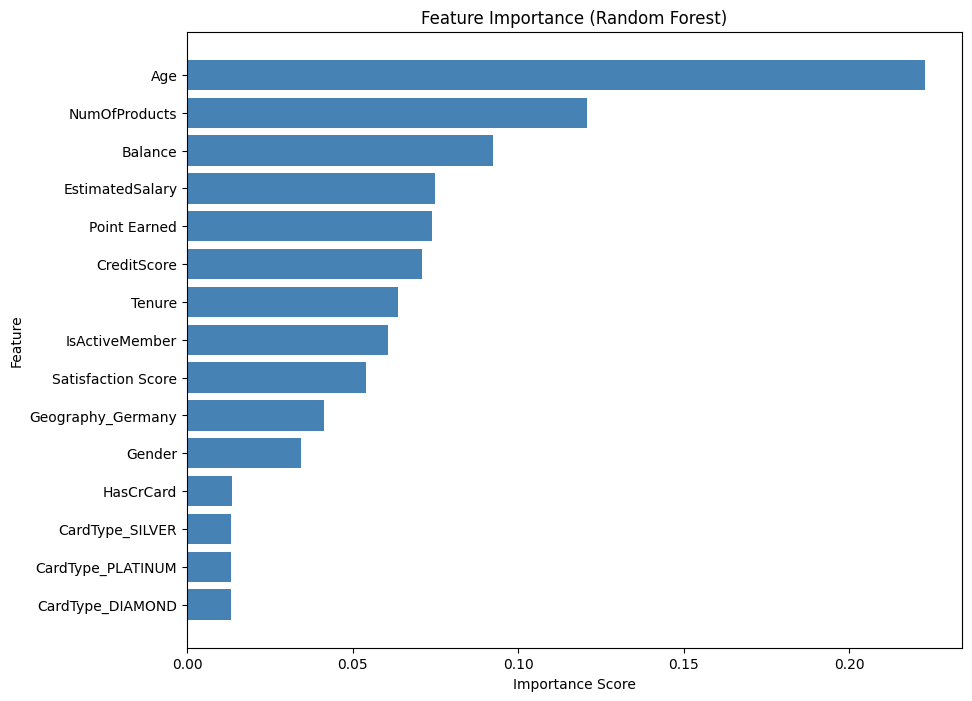

In [41]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))

top_features = feature_importance_df.head(15)
ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance (Random Forest)')
ax.invert_yaxis()

plt.savefig('figure_09_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# **RQ2. Expected Financial Exposure Calculation**

In [45]:
# Get test set indices to retrieve Balance
test_indices = X_test.index

# Create results DataFrame
results_df = pd.DataFrame({
    'CustomerIndex': test_indices,
    'ActualChurn': y_test.values,
    'PredictedChurn': y_pred,
    'ChurnProbability': y_pred_proba,
    'Balance': df.loc[test_indices, 'Balance'].values
})

# Calculate Expected Financial Exposure
results_df['ExpectedLoss'] = results_df['ChurnProbability'] * results_df['Balance']

# Sort by Expected Loss (highest risk first)
results_df = results_df.sort_values('ExpectedLoss', ascending=False).reset_index(drop=True)


print("\nFormula: Expected Loss = P(Churn) × Account Balance")
print("\nTop 10 Highest Risk Customers:")
print(results_df[['CustomerIndex', 'ChurnProbability', 'Balance', 'ExpectedLoss', 'ActualChurn']].head(10))



Formula: Expected Loss = P(Churn) × Account Balance

Top 10 Highest Risk Customers:
   CustomerIndex  ChurnProbability   Balance  ExpectedLoss  ActualChurn
0           2092              0.60 250898.09     150169.82            1
1           8982              0.66 206663.75     136731.55            0
2           3175              0.81 164769.02     133506.17            1
3           2658              0.69 164948.98     114562.19            1
4           7212              0.60 190066.54     113298.00            1
5            867              0.66 170833.46     113242.65            1
6           5082              0.78 142880.28     111105.54            1
7           8861              0.59 178074.33     104392.29            0
8            989              0.61 168197.66     103306.08            1
9           7435              0.78 130554.51     102372.28            1


In [50]:
# Compare probability-based vs. financial-based prioritization
results_prob_sorted = results_df.sort_values('ChurnProbability', ascending=False).reset_index(drop=True)
results_loss_sorted = results_df.sort_values('ExpectedLoss', ascending=False).reset_index(drop=True)

# Check overlap in top 100 customers
top_100_prob = set(results_prob_sorted.head(100)['CustomerIndex'])
top_100_loss = set(results_loss_sorted.head(100)['CustomerIndex'])
overlap = len(top_100_prob.intersection(top_100_loss))


print(f"\nTop 100 by Churn Probability vs. Top 100 by Expected Loss:")
print(f"  Overlap: {overlap} customers ({overlap}%)")
print(f"  Different: {100 - overlap} customers ({100-overlap}%)")


Top 100 by Churn Probability vs. Top 100 by Expected Loss:
  Overlap: 32 customers (32%)
  Different: 68 customers (68%)


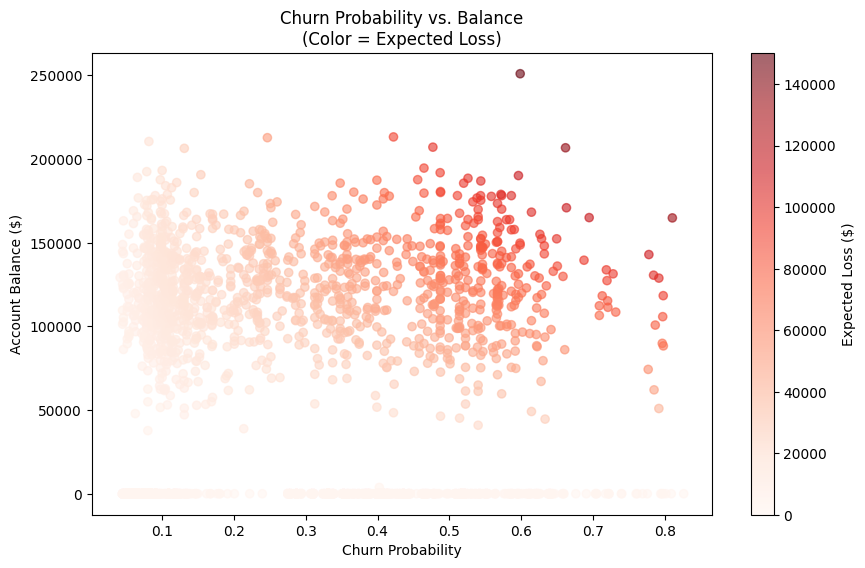

In [51]:
# Visualize the difference
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# Scatter: Probability vs Balance
scatter = axes.scatter(results_df['ChurnProbability'],
                       results_df['Balance'],
                       c=results_df['ExpectedLoss'],
                       cmap='Reds',
                       alpha=0.6)
axes.set_xlabel('Churn Probability')
axes.set_ylabel('Account Balance ($)')
axes.set_title('Churn Probability vs. Balance\n(Color = Expected Loss)')
plt.colorbar(scatter, ax=axes, label='Expected Loss ($)')

plt.savefig('figure_10_financial_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

# **RQ3: Cost Sensitive Intervention Thresholding **

In [67]:
# Define cost framework
INTERVENTION_COST = 200  # Cost to attempt retention (this is as assumption)
RETENTION_SUCCESS_RATE = 0.30  # Assume 30% of interventions successfully prevent churn (this is an assumption)

print(f"\nAssumptions:")
print(f"  Intervention Cost: ${INTERVENTION_COST} per customer")
print(f"  Retention Success Rate: {RETENTION_SUCCESS_RATE*100}%")
print(f"  Financial Exposure: Account Balance")
print(f"  Financial Exposure: Unlimited Resources - this will be addressed in the assignment")

# Test different probability thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_results = []

for threshold in thresholds_to_test:
    # Identify customers to target
    targeted = results_df[results_df['ChurnProbability'] >= threshold].copy()

    # Calculate metrics
    num_targeted = len(targeted)
    total_intervention_cost = num_targeted * INTERVENTION_COST
    expected_loss_prevented = (targeted['ExpectedLoss'] * RETENTION_SUCCESS_RATE).sum()
    net_benefit = expected_loss_prevented - total_intervention_cost

    threshold_results.append({
        'Threshold': threshold,
        'CustomersTargeted': num_targeted,
        'InterventionCost': total_intervention_cost,
        'ExpectedLossPrevented': expected_loss_prevented,
        'NetBenefit': net_benefit
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis Results:")
print(threshold_df.to_string(index=False))


Assumptions:
  Intervention Cost: $200 per customer
  Retention Success Rate: 30.0%
  Financial Exposure: Account Balance
  Financial Exposure: Unlimited Resources - this will be addressed in RQ3

Threshold Analysis Results:
 Threshold  CustomersTargeted  InterventionCost  ExpectedLossPrevented  NetBenefit
      0.30                856            171200             9217919.04  9046719.04
      0.40                598            119600             7232652.29  7113052.29
      0.50                373             74600             5042910.84  4968310.84
      0.60                113             22600             1372702.77  1350102.77
      0.70                 40              8000              528210.86   520210.86
      0.80                  4               800               40051.85    39251.85


In [68]:
# Find optimal threshold
optimal_idx = threshold_df['NetBenefit'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']
optimal_net_benefit = threshold_df.loc[optimal_idx, 'NetBenefit']

print(f"\nThreshold: {optimal_threshold} (Target customers with ≥{optimal_threshold*100}% churn probability)")
print(f"Net Benefit: ${optimal_net_benefit:,.2f}")
print(f"Customers Targeted: {threshold_df.loc[optimal_idx, 'CustomersTargeted']}")
print(f"Total Intervention Cost: ${threshold_df.loc[optimal_idx, 'InterventionCost']:,.2f}")
print(f"Expected Loss Prevented: ${threshold_df.loc[optimal_idx, 'ExpectedLossPrevented']:,.2f}")


Threshold: 0.3 (Target customers with ≥30.0% churn probability)
Net Benefit: $9,046,719.04
Customers Targeted: 856
Total Intervention Cost: $171,200.00
Expected Loss Prevented: $9,217,919.04


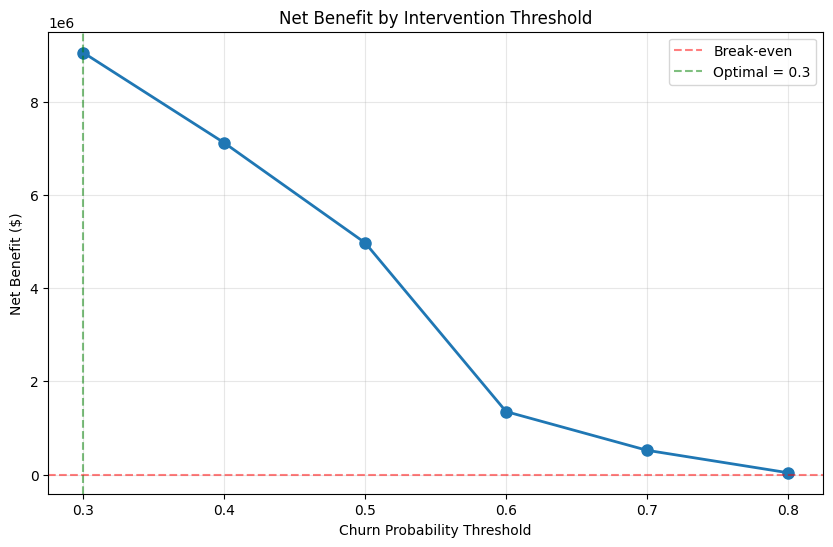

In [69]:
# Visualize threshold optimization
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Better size for single plot

# Net Benefit by Threshold
axes.plot(threshold_df['Threshold'], threshold_df['NetBenefit'], 'o-', linewidth=2, markersize=8)
axes.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
axes.axvline(optimal_threshold, color='green', linestyle='--', alpha=0.5,
             label=f'Optimal = {optimal_threshold}')
axes.set_xlabel('Churn Probability Threshold')
axes.set_ylabel('Net Benefit ($)')
axes.set_title('Net Benefit by Intervention Threshold')
axes.legend()
axes.grid(True, alpha=0.3)

plt.savefig('figure_11_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()
